# AULA 02 - DADOS QUALITATIVOS

## EXEMPLO
Para adequar os produtos às preferências dos clientes, um projetista de páginas de Internet pretende conhecer o perfil dos indivíduos que acessam um de seus sites. Pensando nisso, ele fez uma pesquisa e levantou algumas características dos visitantes de seu site, tais como o sexo, a idade, o nível de instrução e o provedor utilizado. Geralmente esse tipo de pesquisa envolve centenas ou milhares de respondentes, mas aqui consideraremos apenas uma amostra de 40 pessoas.

### BIBLIOTECAS E IMPORTANTO DADOS

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("amostra_visitantes.csv")

In [4]:
df.head(5)

,Sexo,Idade,Nível de Instrução,Provedor de Internet
0,Feminino,30,Superior,Provedor C
1,Masculino,18,Médio,Provedor B
2,Masculino,51,Superior,Provedor A
3,Feminino,35,Pós-graduação,Provedor A
4,Masculino,21,Médio,Provedor A


### ANALISANDO VALORES AUSENTES

In [5]:
df.isna().sum()

Sexo                    0
Idade                   0
Nível de Instrução      0
Provedor de Internet    0
dtype: int64

### MEDIDAS DESCRITIVAS

In [6]:
for qualidades in ["Sexo", "Nível de Instrução", "Provedor de Internet"]:
    print(f"# FREQUÊNCIA ABSOLUTA - {qualidades}")
    display(df.groupby(qualidades)[qualidades].value_counts())

    print(f"# FREQUÊNCIA RELATIVA - {qualidades}")
    display(df.groupby(qualidades)[qualidades].value_counts()/df.shape[0]*100)
    
    print(f"# MODA: {df[qualidades].mode().to_list()}\n\n")

# FREQUÊNCIA ABSOLUTA - Sexo


Sexo
Feminino     20
Masculino    20
Name: count, dtype: int64

# FREQUÊNCIA RELATIVA - Sexo


Sexo
Feminino     50.0
Masculino    50.0
Name: count, dtype: float64

# MODA: ['Feminino', 'Masculino']


# FREQUÊNCIA ABSOLUTA - Nível de Instrução


...

# MODA: ['Superior']


# FREQUÊNCIA ABSOLUTA - Provedor de Internet


Provedor de Internet
Provedor A    13
Provedor B    10
Provedor C    13
Provedor D     4
Name: count, dtype: int64

# FREQUÊNCIA RELATIVA - Provedor de Internet


Provedor de Internet
Provedor A    32.5
Provedor B    25.0
Provedor C    32.5
Provedor D    10.0
Name: count, dtype: float64

# MODA: ['Provedor A', 'Provedor C']




In [7]:
pd.crosstab(df["Sexo"], df["Nível de Instrução"])

Nível de Instrução,Fundamental,Médio,Pós-graduação,Superior
Sexo,,,,
Feminino,4,7,3,6
Masculino,4,5,4,7


In [8]:
pd.crosstab(df["Sexo"], df["Provedor de Internet"])

Provedor de Internet,Provedor A,Provedor B,Provedor C,Provedor D
Sexo,,,,
Feminino,6,5,8,1
Masculino,7,5,5,3


In [9]:
pd.crosstab(df["Nível de Instrução"], df["Provedor de Internet"])

Provedor de Internet,Provedor A,Provedor B,Provedor C,Provedor D
Nível de Instrução,,,,
Fundamental,2,2,4,0
Médio,3,4,3,2
Pós-graduação,3,3,1,0
Superior,5,1,5,2


In [10]:
pd.crosstab(df["Sexo"], df["Nível de Instrução"], values=df["Idade"], aggfunc="mean")

Nível de Instrução,Fundamental,Médio,Pós-graduação,Superior
Sexo,,,,
Feminino,37.25,41.142857,30.333333,27.666667
Masculino,24.50,35.400000,52.750000,46.000000


### GRÁFICOS

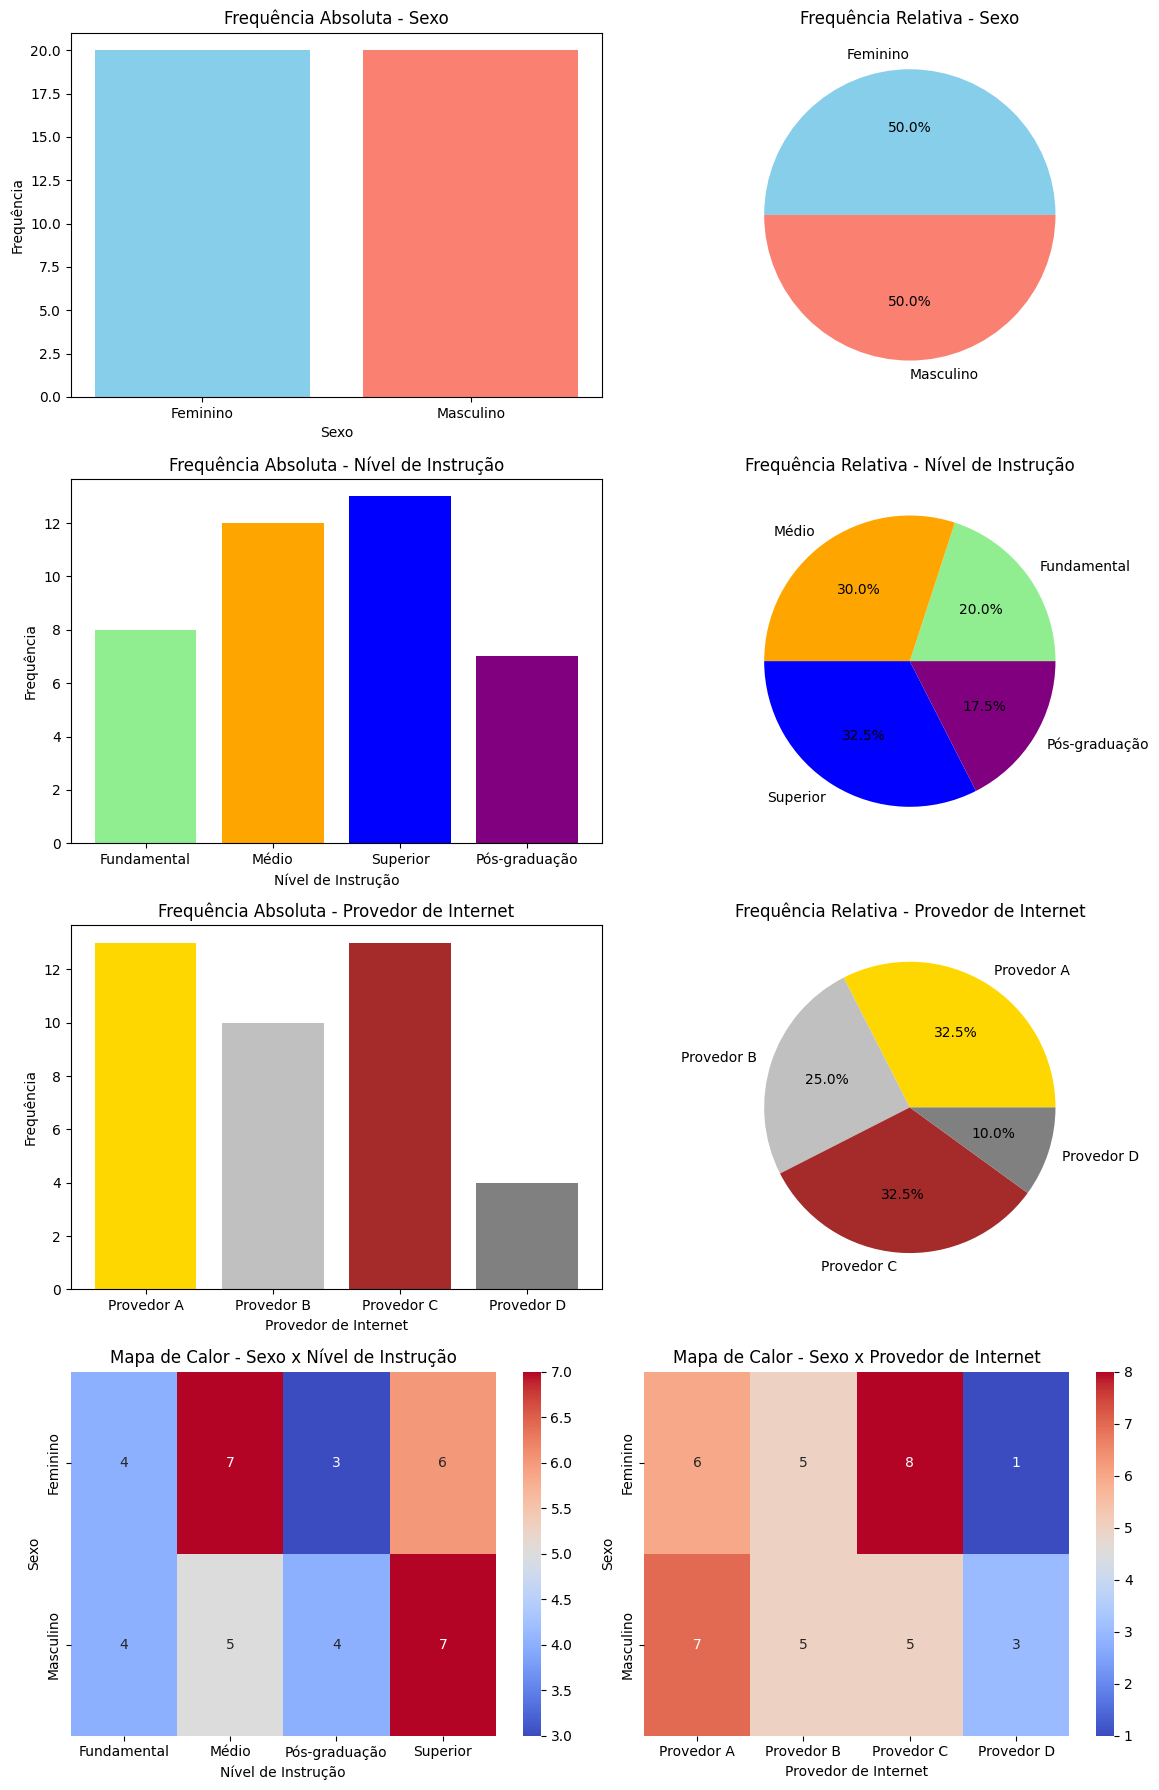

In [11]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(12, 18))



plt.subplot(4, 2, 1)
sexo_counts = df["Sexo"].value_counts()
sexo_labels = sexo_counts.index.tolist()
sexo_values = sexo_counts.values.tolist()

plt.bar(sexo_labels, sexo_values, color=["skyblue", "salmon"])
plt.title("Frequência Absoluta - Sexo")
plt.ylabel("Frequência")
plt.xlabel("Sexo")

plt.subplot(4, 2, 2)
plt.pie(sexo_values, labels=sexo_labels, autopct="%1.1f%%", colors=["skyblue", "salmon"])
plt.title("Frequência Relativa - Sexo")



plt.subplot(4, 2, 3)
ordem_instrucao = ["Fundamental", "Médio", "Superior", "Pós-graduação"]
instrucao_counts = df["Nível de Instrução"].value_counts().reindex(ordem_instrucao)
instrucao_labels = instrucao_counts.index.tolist()
instrucao_values = instrucao_counts.values.tolist()

plt.bar(instrucao_labels, instrucao_values, color=["lightgreen", "orange", "blue", "purple"])
plt.title("Frequência Absoluta - Nível de Instrução")
plt.ylabel("Frequência")
plt.xlabel("Nível de Instrução")

plt.subplot(4, 2, 4)
plt.pie(instrucao_values, labels=instrucao_labels, autopct="%1.1f%%", colors=["lightgreen", "orange", "blue", "purple"])
plt.title("Frequência Relativa - Nível de Instrução")



plt.subplot(4, 2, 5)
ordem_provedor = ["Provedor A", "Provedor B", "Provedor C", "Provedor D"]
provedor_counts = df["Provedor de Internet"].value_counts().reindex(ordem_provedor)
provedor_labels = provedor_counts.index.tolist()
provedor_values = provedor_counts.values.tolist()

plt.bar(provedor_labels, provedor_values, color=["gold", "silver", "brown", "grey"])
plt.title("Frequência Absoluta - Provedor de Internet")
plt.ylabel("Frequência")
plt.xlabel("Provedor de Internet")

plt.subplot(4, 2, 6)
plt.pie(provedor_values, labels=provedor_labels, autopct="%1.1f%%", colors=["gold", "silver", "brown", "grey"])
plt.title("Frequência Relativa - Provedor de Internet")



plt.subplot(4, 2, 7)
contigencia = pd.crosstab(df["Sexo"], df["Nível de Instrução"])
sns.heatmap(contigencia, annot=True, cmap="coolwarm")
plt.title("Mapa de Calor - Sexo x Nível de Instrução")

plt.subplot(4, 2, 8)
contigencia = pd.crosstab(df["Sexo"], df["Provedor de Internet"])
sns.heatmap(contigencia, annot=True, cmap="coolwarm")
plt.title("Mapa de Calor - Sexo x Provedor de Internet")



plt.tight_layout()
plt.show()


### VALORES AUSENTES

In [12]:
df_ausente = df.copy(deep=True)

remover = df_ausente['Sexo'].sample(frac=0.05, random_state=52)
for idx in remover.index.to_list():
    df_ausente.loc[idx, "Sexo"] = pd.NA

remover = df_ausente['Nível de Instrução'].sample(frac=0.05, random_state=104)
for idx in remover.index.to_list():
    df_ausente.loc[idx, "Nível de Instrução"] = pd.NA

remover = df_ausente['Provedor de Internet'].sample(frac=0.05, random_state=208)
for idx in remover.index.to_list():
    df_ausente.loc[idx, "Provedor de Internet"] = pd.NA

In [13]:
df_ausente.isna().sum()

Sexo                    2
Idade                   0
Nível de Instrução      2
Provedor de Internet    2
dtype: int64

In [14]:
df_ausente[df_ausente["Sexo"].isnull()]

,Sexo,Idade,Nível de Instrução,Provedor de Internet
8,<NA>,50,Superior,Provedor A
36,<NA>,56,Médio,Provedor B


Como não existe uma moda única para a a categoria `Sexo`. Devemos analisar a **Tabela de Contigência** para encontrar uma relação com os os valores da tabela ou fazer um teste de hipótese **Qui-Quadrado de Independência**.

In [15]:
df_ausente[df_ausente["Nível de Instrução"].isnull()]

,Sexo,Idade,Nível de Instrução,Provedor de Internet
4,Masculino,21,<NA>,Provedor A
16,Feminino,37,<NA>,Provedor C


In [16]:
df_ausente[df_ausente["Provedor de Internet"].isnull()]

,Sexo,Idade,Nível de Instrução,Provedor de Internet
15,Masculino,25,Fundamental,<NA>
29,Feminino,36,Pós-graduação,<NA>
